In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import sys
import os
sys.path.append(os.path.abspath("../.."))

import utils.plot as pu

In [2]:
# Perceptron Model 
# hyperparameters - eta, n_iter
# X - (examples, features)
# y - (examples,)
# w - (features,)

class Perceptron :
    def __init__(self, n_iter=50, eta=0.01, random_state=1):
        self.n_iter = n_iter
        self.eta = eta
        self.random_state = random_state


    def fit(self, X, y):
        self.b_ = 0.0
        self.errors_ = []

        rgen = np.random.default_rng(self.random_state)
        self.w_ = rgen.normal(loc=0, scale=0.3, size=X.shape[1])
        # self.w_ = np.zeros(X.shape[1])

        for i in range(self.n_iter):
            errors = 0
            for xi,yi in zip(X,y) :
                y_pdt = self.predict(xi)
                delta = (yi - y_pdt) * self.eta
                
                self.b_ += delta
                self.w_ += (delta * xi)

                if yi != y_pdt:
                    errors += 1  
            
            self.errors_.append(errors)
    
    def predict(self, xi):
        temp = np.dot(xi, self.w_) + self.b_
        return np.where(temp >= 0.0,1,0)
        

In [3]:
# Importing and formatting the data
path = '../data/iris.data'
data = pd.read_csv(path, header=None, encoding='utf-8')
print(data.head())

# setting up input and output
X = data.iloc[0:100, [0,2]].values
print(X[:5])

y = data.iloc[0:100, 4]
y = np.where(y=='Iris-setosa', 1, 0)
print(y[:5])
print(y[95:])


     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa
[[5.1 1.4]
 [4.9 1.4]
 [4.7 1.3]
 [4.6 1.5]
 [5.  1.4]]
[1 1 1 1 1]
[0 0 0 0 0]


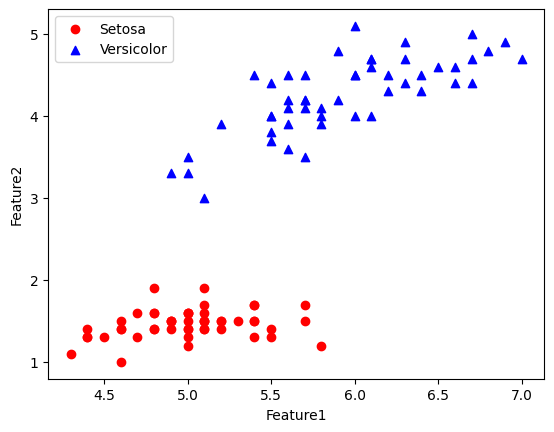

In [4]:
# Checking visually if the data is lineary separable
plt.scatter(X[0:50, 0], X[0:50, 1], marker='o', color='red', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], marker='^', color='blue', label='Versicolor')

plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.legend(loc='upper left')
plt.show()

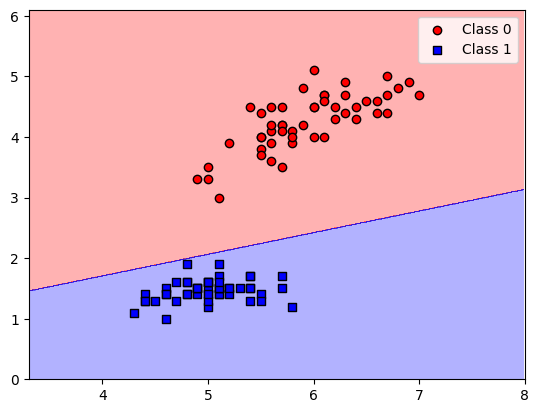

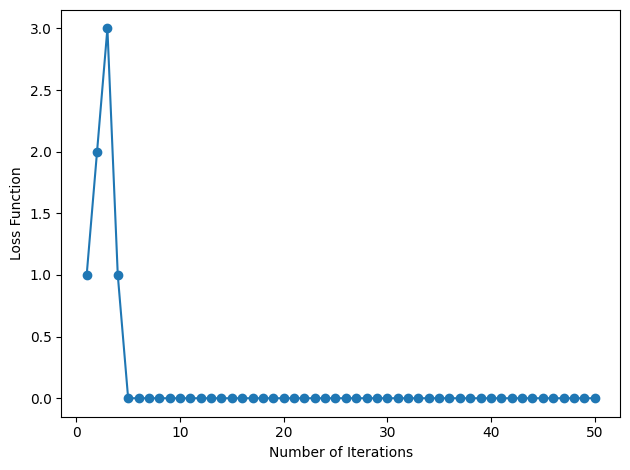

In [9]:
# fitting our data
ppn = Perceptron(n_iter=50,eta=0.05)
ppn.fit(X,y)

pu.plot_decision_regions(X=X, y=y, model=ppn)
plt.show()

pu.plot_loss(ppn.n_iter, ppn.errors_)
plt.show()